### 第16章 图像分割与提取
#### 16.1 分水岭算法实现图像分割与提取
- 在用分水岭算法处理图像前，要先使用开运算（先腐蚀，后膨胀）去除图像内的噪声，以避免噪声对图像分割可能造成的干扰
- 通过原始图像和腐蚀图像的减法运算得到图像的边界
- 一般情况下，用”白色“表示前景，用”黑色“表示背景
$$ 未知区域\text{UN} = 图像 - 确定背景 - 确定前景 $$

- 距离变换函数 `dst = cv2. distanceTransform(src, distanceType, maskSize[, dstType])` 计算二值图像内任意点到最近背景点的距离。一般情况下，计算的是图像内非零值像素点到最近的零值像素点的距离
    - `src` 是 8 位单通道的二值图像
    - `distanceType` 为距离类型参数，包括
        - `cv2.DIST_USER`, `cv2.DIST_L1`, `cv2.DIST_L2`, `cv2.DIST_C`, `cv2.DIST_L12`
        - `cv2.DIST_FAIR`, `cv2.DIST_WELSCH`, `cv2.DIST_HUBER`
    - `maskSize` 为掩膜的尺寸，可选`cv2.DIST_MASK_3`, `cv2.DIST_MASK_5`, `cv2.DIST_MASK_PRECISE`
        - 当`distanceType = cv2.DIST_L1 或 cv2.DIST_C` 时，`maskSize` 强制为3
    - `dstType` 为目标图像的类型，默认值为`CV_32F`
    - `dst` 表示计算得到的目标图像，可以是单通道8位或32位浮点数，尺寸和 src 相同

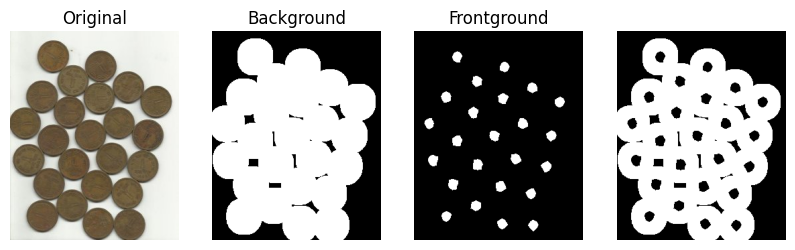

In [5]:
# 标注图像的确定前景、确定背景和未知区域
import numpy as np
import cv2
import matplotlib.pyplot as plt

#  ===========步骤1：图像预处理=================
img = cv2.imread("water_coins.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
#  ==============步骤2：计算确定背景 B==================
kernel = np.ones((3, 3), np.uint8)
Backround = cv2.dilate(opening, kernel, iterations=3)
#  =============步骤3：计算确定前景 F=================
dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, fore = cv2.threshold(dist, 0.7 * dist.max(), 255, 0)
Front = np.uint8(fore)
#  ===========步骤4：计算未知区域 Boundry ==================
Unkown = cv2.subtract(Backround, Front)
#  =============步骤5：显示结果======================
ishow = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # 色彩空间转换，用于plt显示

plt.figure(figsize=(10, 4))
plt.subplot(141)
plt.imshow(ishow)
plt.title("Original")
plt.axis("off")
plt.subplot(142)
plt.imshow(Backround, cmap="gray")
plt.title("Background")
plt.axis("off")
plt.subplot(143)
plt.imshow(Front, cmap="gray")
plt.title("Frontground")
plt.axis("off")
plt.subplot(144)
plt.imshow(Unkown, cmap="gray")
plt.axis("off")
plt.show()

- 函数 `retval, labels = cv2. connectedComponents(image)` 会将图像背景标注为 0，将其他的对象从 1 开始用正整数标注
    - `image` 是 8 位单通道的待标注图像
    - `retval` 为返回的标注数量
    - `labels` 为标注的结果图像

- 函数 `markers = cv2.watershed(image, markers)` 是实现分水岭算法的函数，其中
    - `image` 是输入图像，必须是 8 位三通道的图像
    - `markers` 是32位单通道的标注，函数会在该参数上进行标注处理，并将对该参数的标注结果作为输出值，作为返回值可省略
    - 对于确定分割的区域被标注位正整数，未确定的区域被标注为0。在对image处理时，会直接修改标注区域markers的值，处理后的markers中，每一个像素要么被设置为初期的”种子值”，要么被视为边界值“-1”

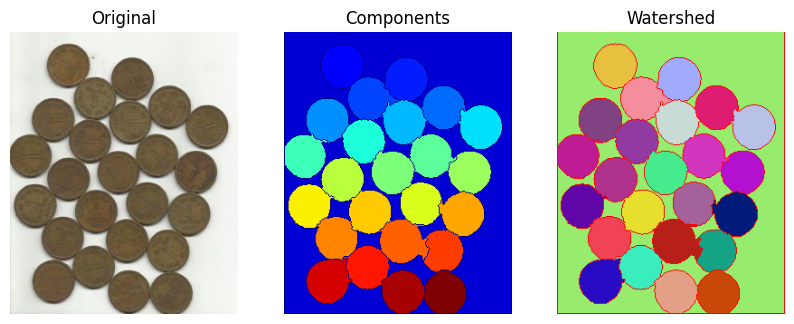

In [20]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
# ==========步骤1：识别区域（确定前景F、确定背景B、未知区域）============
#  ------------步骤1.1：图像预处理-----------------
img = cv2.imread('water_coins.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN,kernel, iterations=2)
#  ------------步骤1.2：计算确定背景B--------------
kernel = np.ones((3,3),np.uint8)
B = cv2.dilate(opening, kernel, iterations=3)
#  ------------步骤1.3：计算确定前景F--------------
dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, fore = cv2.threshold(dist, 0.7*dist.max(), 255,0)
F = np.uint8(fore)
#  -----------步骤1.4：计算未知区域UN--------------
UN = cv2.subtract(B,F)

# =============步骤2：使用函数connectedComponents标注图像 ========
ret, markers = cv2.connectedComponents(F)
# =====步骤3：对函数cv2.connectedComponents()的标注结果进行修订=====
markers = markers + 1  # 数值 1 代表背景区域，从 2 开始代表不同的前景区域
markers[UN==255] = 0   # 将计算出来的未知区域标注为 0，以便将标注结果用于分水岭算法
# print(np.max(markers))   # 25，有24个前景（2-25）

# =============步骤3：使用分水岭函数完成分割 =========
markers = cv2.watershed(img, markers)
# ===============	步骤4：显示处理结果 =============================
#  ------------ 构造分区容器 -----------------
imgWatershed = np.zeros(img.shape, dtype=np.uint8)
#  ------------ 将每一个分区处理为不同颜色 -----------------
for x in range(1, np.max(markers) + 1):
    r = np.random.randint(0, 255)
    g = np.random.randint(0, 255)
    b = np.random.randint(0, 255)
    imgWatershed[markers == x] = [r, g, b]
#  ------------ 将边缘处理为红色 -----------------
imgWatershed[markers == -1] = [0, 0, 255]
#  ------------ 色彩空间转换 -----------------
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
imgWatershed = cv2.cvtColor(imgWatershed, cv2.COLOR_BGR2RGB)

# =====================步骤5：显示=========================
plt.figure(figsize=(10, 4))
plt.subplot(131)
plt.imshow(ishow)
plt.title("Original")
plt.axis("off")

plt.subplot(132)
plt.imshow(markers, cmap="jet")  # "jet" 是一种伪彩色方案，低值显示为蓝色，高值显示为红色
plt.title("Components")
plt.axis('off')

plt.subplot(133)
plt.imshow(imgWatershed, cmap="jet")
plt.title("Watershed")
plt.axis("off")
plt.show()

#### 16.2 交互式前景提取 (GrabCut 算法)
1. 将前景所在的全部区域使用矩形框标注出来
2. 根据矩形框外部的“确定背景”数据，以及“硬标记”，区分矩形框区域内的前景和背景
3. 用高斯混合模型(Gaussians Mixture Model, GMM)对前景和背景建模，对未分类像素根据其与已知分类像素（前景和背景）的关系进行分类
4. 根据像素分布情况生成一张图，图中的各个像素点都是该图中的节点，每一个像素点同时连接到前景节点和背景节点，连接权重由像素是前景或背景的概率决定，此处的权重表示的是一个像素点属于前景或背景的概率，称为“区域权重”
5. 图中每个像素点彼此之间也存在连接，连接权重由它们的相似性决定。两个像素的颜色越接近，边的权重值越大，表示其越不可能是边缘；两个像素的颜色差别越明显，边的权重值越小，表示其越可能是边缘，该权重称为“边缘权重”
6. 完成节点连接后，将图切成具有最小成本函数的两个分离的前景节点集合、背景节点集合，成本函数是被切割边缘的所有权重的总和，要同时考虑区域权重和边缘权重
7. 不断重复上述过程，直至分类收敛为止

- 函数 `mask, bgdModel, fgdModel = cv2.grabCut(img, mask, rect, bgdModel, fgdModel, iterCount[, mode])` 实现交互式前景提取，函数执行完成后，返回值与对应的参数值一致，通常情况可以省略返回值。其中
    - `img` 为输入的 8 位 3 通道图像
    - `mask` 为 8 位单通道的掩膜图像
    - `rect` 指包含前景对象的区域，该区域的外部视为“确定背景”。其格式为(x,y,w,h)，分别表示区域左上角像素的坐标以及区域的宽度和高度。使用掩膜模式时，该值可设为 `None`
    - `bgdModel` 为算法内部背景模型使用的数组，实际创建大小为(1, 65)的 numpy.float64 数组
    - `fgdModel` 为算法内部前景模型使用的数组，实际创建大小为(1, 65)的 numpy.float64 数组
    - `iterCount` 表示迭代的次数
    - `mode` 表示分割模式
        - `cv2.GC_INIT_WITH_RECT` 使用提供的矩形初始化状态和掩码，根据 `iterCount` 指定的迭代次数运行
        - `cv2.GC_INIT_WITH_MASK` 使用自定义模板，`cv2.GC_INIT_WITH_RECT` 和 `cv2.GC_INIT_WITH_MASK` 可组合使用，所有 ROI 区域外（不在模板或矩形指定范围内）的像素会被自动处理为背景
        - `cv2.GC_EVAL` 修复模式
        - `cv2.GC_EVAL——FREEZE_MODEL` 使用固定模式
- `mask` 可以表示为下列4种形式之一：
    - `cv2.GC_BGD` 表示确定背景，也可以用数值 0 表示
    - `cv2.GC_FGD` 表示确定前景，也可以用数值 1 表示
    - `cv2.GC_PR_BGD` 表示可能的背景，也可以用数值 2 表示
    - `cv2.GC_PR_FGD` 表示可能的前景，也可以用数值 3 表示
- `mask` 根据使用模式的不同，使用方法也不同，如下所示：
    - `mode` 为 `cv2.GC_INIT_WITH_RECT` 时，`mask` 可初始化为一个值为 0 的数组，函数运行完成后，`mask` 自动包含前景背景划分信息，可以作为掩膜完成图像分割
    - `mode` 为 `cv2.GC_INIT_WITH_MASK` 时，`mask` 必须为上述4种形式之一，函数运行完成后，`mask` 表示最终的前景背景划分结果，可以作为掩膜完成图像分割
- 提取前景时，需要先将 `mask` 进行处理
    - 将 `mask` 中的数值 0 （确定背景） 和数值 2 （可能的背景） 处理为数值 0 （背景）
    - 将 `mask` 中的数值 1 （确定前景） 和数值 3 （可能的前景） 处理为数值 1 （前景）
- 乘法运算 "$\text{mask} \times 原始图像$"

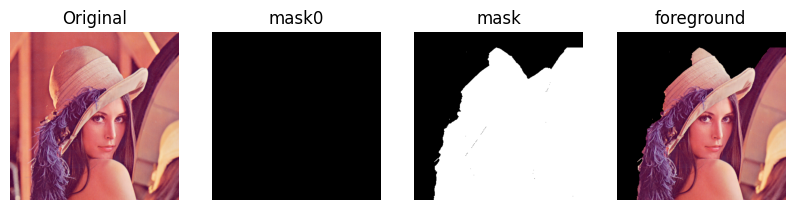

In [ ]:
# 使用 `cv2.GC_INIT_WITH_RECT` 提取前景图像
# ============导入库==============
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ========== 导入原始图像 ============
o = cv2.imread("lenacolor.png")
# ========== mask初始化为0值 ============
mask0 = np.zeros(o.shape[:2], np.uint8)
mask = mask0.copy()
# 函数grabCut会直接修改参数mask的值, 
# 如果不复制mask0的值，在将其作为grabCut参数使用后，其原始值会丢失
# ========== 设置参数bgdModel/fgdModel ============
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)
# ========== 矩形框划定可能前景区域rect，参数rect =========
rect = (50, 50, 512, 512)
# ========== 调用函数grabCut ============
cv2.grabCut(o, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

# ================================================================
# 将mask中的确定背景（数值0）、可能背景（数值2）处理为背景（数值0）
# 将mask中其他区域处理为前景（数值1）
# 对应程序为，将mask中的0、2处理为0，数值1、3处理为1
# ==============================================================
# 如果mask中元素的值等于 2 或等于 0，就输出 0，否则输出 1；再把结果转换为无符号 8 位整数
mask = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")
# ==============================================================
# 将掩模mask与原始图像o相乘实现，将原始图像o中：
# 与mask中0值相对应部分处理为背景（数值处理为0）
# 与mask中1值相对应部分处理为前景（数值保持不变）
# ==============================================================
ogc = o * mask[:, :, np.newaxis]  # 把 mask 扩展成 (H, W, 1)，和彩色图像在最后一个通道上广播匹配。
# ==========显示原始图像、前景图像============
o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
mask0 = cv2.cvtColor(mask0, cv2.COLOR_GRAY2RGB)
mask = cv2.cvtColor(mask*255, cv2.COLOR_GRAY2RGB)
ogc = cv2.cvtColor(ogc, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 4))
plt.subplot(141)
plt.imshow(o)
plt.title("Original")
plt.axis("off")

plt.subplot(142)
plt.imshow(mask0)
plt.title("mask0")
plt.axis("off")

plt.subplot(143)
plt.imshow(mask)
plt.title("mask")
plt.axis("off")

plt.subplot(144)
plt.imshow(ogc)
plt.title("foreground")
plt.axis("off")
plt.show()

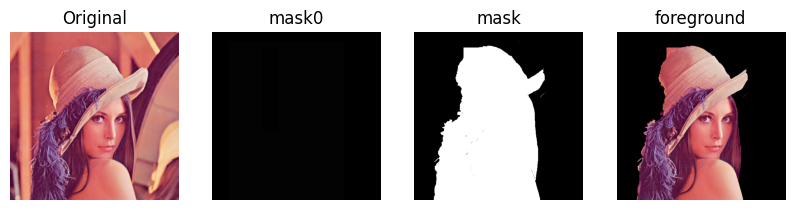

In [ ]:
# 使用 `cv2.GC_INIT_WITH_MASK` 提取前景图像
# ============导入库==============
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ========== 导入原始图像 ============
o = cv2.imread("lenacolor.png")
# ========== 设置初始模板mask0 ============
mask0 = np.zeros(o.shape[:2], np.uint8)
mask0[30:512, 50:400] = 3
mask0[50:300, 150:200] = 1
mask = mask0.copy()
# 函数grabCut会直接修改参数mask的值,
# 如果不复制mask0的值，在将其作为grabCut参数使用后，其原始值会丢失
# ========== 设置参数bgdModel/fgdModel ============
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)
# ========== 矩形框划定可能前景区域rect，参数rect =========
rect = (50, 50, 512, 512)
# ========== 调用函数grabCut ============
cv2.grabCut(o, mask, None, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_MASK)
# ================================================================
# 将mask中的确定背景（数值0）、可能背景（数值2）处理为背景（数值0）
# 将mask中其他区域处理为前景（数值1）
# 对应程序为，将mask中的0、2处理为0，数值1、3处理为1
# ==============================================================
# 如果mask中元素的值等于 2 或等于 0，就输出 0，否则输出 1；再把结果转换为无符号 8 位整数
mask = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")
# ==============================================================
# 将掩模mask与原始图像o相乘实现，将原始图像o中：
# 与mask中0值相对应部分处理为背景（数值处理为0）
# 与mask中1值相对应部分处理为前景（数值保持不变）
# ==============================================================
ogc = o * mask[:, :, np.newaxis]  # 把 mask 扩展成 (H, W, 1)，和彩色图像在最后一个通道上广播匹配。
# ==========显示原始图像、前景图像============
o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
mask0 = cv2.cvtColor(mask0, cv2.COLOR_GRAY2RGB)
mask = cv2.cvtColor(mask * 255, cv2.COLOR_GRAY2RGB)
ogc = cv2.cvtColor(ogc, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 4))
plt.subplot(141)
plt.imshow(o)
plt.title("Original")
plt.axis("off")

plt.subplot(142)
plt.imshow(mask0)
plt.title("mask0")
plt.axis("off")

plt.subplot(143)
plt.imshow(mask)
plt.title("mask")
plt.axis("off")

plt.subplot(144)
plt.imshow(ogc)
plt.title("foreground")
plt.axis("off")
plt.show()

##### 手绘模板提取

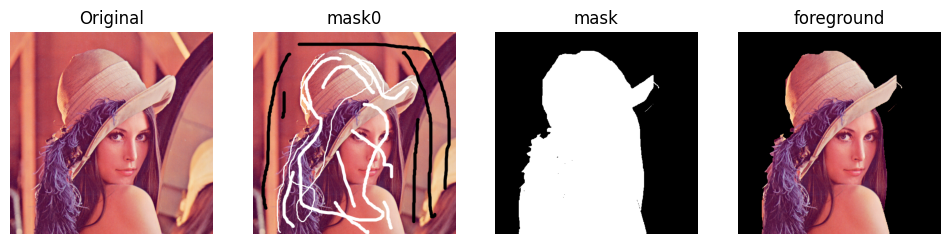

In [25]:
# ============导入库==============
import numpy as np
import cv2
# ==========导入原始图像============
o = cv2.imread('lenacolor.png')
# =====================================================================
# 在cv2.GC_INIT_WITH_RECT模式下,对图像进行初步的前景提取
# 此步骤的目的是获取mask，为后续cv2.GC_INIT_WITH_MASK模式做准备
# ===================================================================
mask = np.zeros(o.shape[:2],np.uint8)
bgdModel = np.zeros((1,65),np.float64)
fgdModel = np.zeros((1,65),np.float64)
rect = (50, 50, 350, 512)
cv2.grabCut(o, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)
# ===============读入手工掩模图像mask0，单通道处理为mask2=============
mask0 = cv2.imread("mask2.png", cv2.IMREAD_COLOR)
mask2 = cv2.cvtColor(mask0, cv2.COLOR_BGR2GRAY)
# ===================================================================
# 将手动标注的前景、背景映射到模板mask中，具体为： 
# 将掩模图像中，与mask2中黑色线条对应位置的值（对应像素值0）设置为0
# 将掩模图像中，与mask2中白色线条对应位置的值（对应像素值255）设置为1
# ===================================================================
mask[mask2 == 0] = 0
mask[mask2 == 255] = 1
# ===================================================================
# 调用函数grabCut，此时模式为：cv2.GC_INIT_WITH_MASK，注意rect参数为None
# ===================================================================
cv2.grabCut(o, mask, None, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_MASK)
# =======调整mask值===============
mask = np.where((mask==2)|(mask==0), 0, 1).astype('uint8')
# =======设置前景区域===============
fore = o * mask[:, :, np.newaxis]
# ==========显示图像============
# print("mask2.shape:", mask2.shape)  # mask2.shape: (512, 512)
# print("mask.shape:", mask.shape)  # mask.shape: (512, 512)
# print("fore.shape:", fore.shape)  # fore.shape: (512, 512, 3)

o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
mask0 = cv2.cvtColor(mask0, cv2.COLOR_BGR2RGB)
mask = cv2.cvtColor(mask * 255, cv2.COLOR_BGR2RGB)
fore = cv2.cvtColor(fore, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 4))
plt.subplot(141)
plt.imshow(o)
plt.title("Original")
plt.axis("off")

plt.subplot(142)
plt.imshow(mask0)
plt.title("mask0")
plt.axis("off")

plt.subplot(143)
plt.imshow(mask)
plt.title("mask")
plt.axis("off")

plt.subplot(144)
plt.imshow(fore)
plt.title("foreground")
plt.axis("off")
plt.show()


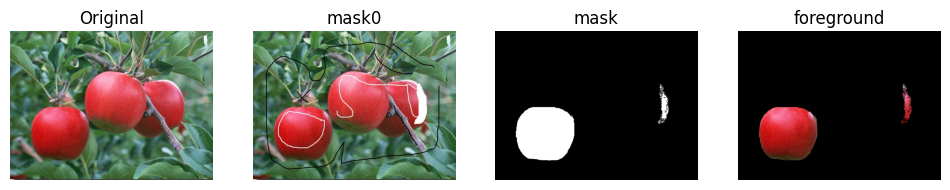

In [24]:
# ============导入库==============
import numpy as np
import cv2
# ==========导入原始图像============
o = cv2.imread("apple.jpg")
# =====================================================================
# 在cv2.GC_INIT_WITH_RECT模式下,对图像进行初步的前景提取
# 此步骤的目的是获取mask，为后续cv2.GC_INIT_WITH_MASK模式做准备
# ===================================================================
mask = np.zeros(o.shape[:2], np.uint8)
bgdModel = np.zeros((1,65), np.float64)
fgdModel = np.zeros((1,65), np.float64)
rect = (50, 50, 350, 512)
cv2.grabCut(o, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)
# ===============读入手工掩模图像mask0，单通道处理为mask2=============
mask0 = cv2.imread("applemask.jpg", cv2.IMREAD_COLOR)
mask2 = cv2.cvtColor(mask0, cv2.COLOR_BGR2GRAY)
# ===================================================================
# 将手动标注的前景、背景映射到模板mask中，具体为： 
# 将掩模图像中，与mask2中黑色线条对应位置的值（对应像素值0）设置为0
# 将掩模图像中，与mask2中白色线条对应位置的值（对应像素值255）设置为1
# ===================================================================
mask[mask2 == 0] = 0
mask[mask2 == 255] = 1
# ===================================================================
# 调用函数grabCut，此时模式为：cv2.GC_INIT_WITH_MASK，注意rect参数为None
# ===================================================================
cv2.grabCut(o, mask, None, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_MASK)
# =======调整mask值===============
mask = np.where((mask==2)|(mask==0), 0, 1).astype('uint8')
# =======设置前景区域===============
fore = o * mask[:, :, np.newaxis]
# ==========显示图像============
# print("mask2.shape:", mask2.shape)  # mask2.shape: (572, 778)
# print("mask.shape:", mask.shape)  # mask.shape: (572, 778)
# print("fore.shape:", fore.shape)  # fore.shape: (572, 778, 3)
o = cv2.cvtColor(o, cv2.COLOR_BGR2RGB)
mask0 = cv2.cvtColor(mask0, cv2.COLOR_BGR2RGB)
mask = cv2.cvtColor(mask * 255, cv2.COLOR_BGR2RGB)
fore = cv2.cvtColor(fore, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 4))
plt.subplot(141)
plt.imshow(o)
plt.title("Original")
plt.axis("off")

plt.subplot(142)
plt.imshow(mask0)
plt.title("mask0")
plt.axis("off")

plt.subplot(143)
plt.imshow(mask)
plt.title("mask")
plt.axis("off")

plt.subplot(144)
plt.imshow(fore)
plt.title("foreground")
plt.axis("off")
plt.show()